# Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Input data

In [25]:
stores = pd.read_csv('/Users/danna/Desktop/ITBA/2025 2C/Proyecto-Final/churn-bite/data/raw/stores_data.csv')
orders = pd.read_csv('/Users/danna/Desktop/ITBA/2025 2C/Proyecto-Final/churn-bite/data/raw/orders_data.csv') 
connectivity = pd.read_csv('/Users/danna/Desktop/ITBA/2025 2C/Proyecto-Final/churn-bite/data/raw/connectivity_data.csv')
stages = pd.read_csv('/Users/danna/Desktop/ITBA/2025 2C/Proyecto-Final/churn-bite/data/raw/stages_data.csv')

In [11]:
stores.info()
stores.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10055 entries, 0 to 10054
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   created_date     10055 non-null  object 
 1   status           10055 non-null  object 
 2   segmento         10054 non-null  object 
 3   comision_actual  9532 non-null   float64
 4   logistic_type    10055 non-null  object 
 5   store_type       9718 non-null   object 
 6   barrio           9035 non-null   object 
 7   category         9324 non-null   object 
 8   cooking_time     9687 non-null   object 
 9   tiene_otra_app   9718 non-null   object 
 10  brand_id         8024 non-null   float64
 11  store_id         10055 non-null  int64  
dtypes: float64(2), int64(1), object(9)
memory usage: 942.8+ KB


,created_date,status,segmento,comision_actual,logistic_type,store_type,barrio,category,cooking_time,tiene_otra_app,brand_id,store_id
0,2025-09-16T22:45:34.792Z,active,Microstores,42.0,3P,New brand,BOULOGNE SUR MER,Sándwiches,20 min,No,11060.0,107643
1,2025-09-16T22:10:44.806Z,active,Microstores,42.0,3P,New brand,NUEVA CORDOBA,China,25 min,Sí,13049.0,100827
2,2025-09-16T21:24:41.804Z,active,Microstores,42.0,3P,New brand,RAMOS MEJÍA,Empanadas,10 min,No,11689.0,107223
3,2025-09-16T21:09:19.795Z,active,Microstores,42.0,3P,New brand,LA PLATA,Desayunos y meriendas,30 min,No,11955.0,102438
4,2025-09-16T21:08:58.784Z,active,Microstores,42.0,3P,New brand,MONTE CASTRO,Sándwiches,5 min,No,14502.0,112782


In [6]:
orders.info()
orders.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1867259 entries, 0 to 1867258
Data columns (total 11 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   created_date            object 
 1   APP_ORIGIN              object 
 2   markdown                float64
 3   free_shipping_flag      int64  
 4   promedio_shipping_cost  float64
 5   store_id                float64
 6   TPN                     int64  
 7   TPV                     float64
 8   GMV_LC                  float64
 9   month                   int64  
 10  year                    int64  
dtypes: float64(5), int64(4), object(2)
memory usage: 156.7+ MB


,created_date,APP_ORIGIN,markdown,free_shipping_flag,promedio_shipping_cost,store_id,TPN,TPV,GMV_LC,month,year
0,2024-01-01,MP_IOS_WALLET,0.0,1,1030.75,113911.0,2,41200.0,20600.0,1,2024
1,2024-01-01,MP_ANDROID_WALLET,0.0,1,1018.09,113087.0,2,13000.0,13000.0,1,2024
2,2024-01-01,MP_ANDROID_WALLET,0.0,1,1018.96,107298.0,34,405200.0,229200.0,1,2024
3,2024-01-01,MP_IOS_WALLET,0.0,1,1030.75,112366.0,2,138000.0,23000.0,1,2024
4,2024-01-01,MP_IOS_WALLET,0.0,1,1015.07,115169.0,6,34000.0,34000.0,1,2024


In [7]:
stages.info()
stages.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126769 entries, 0 to 126768
Data columns (total 6 columns):
 #   Column                            Non-Null Count   Dtype 
---  ------                            --------------   ----- 
 0   year                              126769 non-null  int64 
 1   month                             126769 non-null  int64 
 2   cus_cust_id                       126769 non-null  int64 
 3   STORE_STAGE_LIFECYCLE             126769 non-null  object
 4   STORE_STAGE_LIFECYCLE_PREV_MONTH  126769 non-null  object
 5   store_id                          126769 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 5.8+ MB


,year,month,cus_cust_id,STORE_STAGE_LIFECYCLE,STORE_STAGE_LIFECYCLE_PREV_MONTH,store_id
0,2025,8,2541287953,New,Churn > 3M,101932
1,2025,8,148176177,New,Churn > 3M,104879
2,2025,8,135714516,New,Churn > 3M,107831
3,2025,7,291182014,Churn > 3M,Churn > 3M,115356
4,2025,4,291182014,Churn > 3M,Churn > 3M,115356


In [9]:
connectivity.info()
connectivity.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1931962 entries, 0 to 1931961
Data columns (total 6 columns):
 #   Column             Dtype  
---  ------             -----  
 0   created_date       object 
 1   TOTAL_MIN_OPEN     float64
 2   TOTAL_MIN_PAUSED   float64
 3   TOTA_MIN_CLOSED    float64
 4   TOTAL_MINUTES_ALL  float64
 5   store_id           int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 88.4+ MB


,created_date,TOTAL_MIN_OPEN,TOTAL_MIN_PAUSED,TOTA_MIN_CLOSED,TOTAL_MINUTES_ALL,store_id
0,2024-11-19,88.1593,0.0000,11.8407,100.0,112005
1,2024-11-19,99.1111,0.0000,0.8889,100.0,113658
2,2024-11-19,68.6111,0.0000,31.3889,100.0,111289
3,2024-11-19,89.0476,5.9524,5.0000,100.0,110933
4,2024-11-19,65.7401,34.2599,0.0000,100.0,107701


# Data cleaning

In [26]:
# Función para normalizar los nombres de los barrios
def normalize_barrio(barrio):
    normalization_dict = {
        'Agronomia': 'Agronomia', 'Agronomía': 'Agronomia',
        'Monserrat': 'Monserrat', 'Montserrat': 'Monserrat',
        'Nuñez': 'Nunez', 'Núñez': 'Nunez',
        'Villa General Mitre': 'Villa General Mitre', 'Villa Gral. Mitre': 'Villa General Mitre',
        'Villa Ortuzar': 'Villa Ortuzar', 'Villa Ortúzar': 'Villa Ortuzar',
        'Villa Pueyrredon': 'Villa Pueyrredon', 'Villa Pueyrredón': 'Villa Pueyrredon',
        'Villa del Parque': 'Villa Del Parque', 'Villa Del Parque': 'Villa Del Parque',
        'Vélez Sársfield': 'Velez Sarsfield', 'Velez Sarsfield': 'Velez Sarsfield',
        'Santa Rita': 'Villa Santa Rita', 'Villa Santa Rita': 'Villa Santa Rita',
        'Paternal': 'La Paternal', 'La Paternal': 'La Paternal'
    }
    # Normalizar
    return normalization_dict.get(barrio, barrio).lower().replace('á', 'a').replace('é', 'e').replace('í', 'i').replace('ó', 'o').replace('ú', 'u')

# Función para asignar la ciudad basada en el barrio
def assign_city(barrio):
    barrios_caba = [
        'agronomia', 'almagro', 'balvanera', 'barracas', 'belgrano', 'boedo', 'caballito', 'chacarita',
        'coghlan', 'colegiales', 'constitucion', 'flores', 'floresta', 'la boca', 'la paternal', 'liniers',
        'mataderos', 'monserrat', 'monte castro', 'nueva pompeya', 'nunez', 'palermo', 'parque avellaneda',
        'parque chacabuco', 'parque chas', 'parque patricios', 'puerto madero', 'recoleta', 'retiro', 'saavedra',
        'san cristobal', 'san nicolas', 'san telmo', 'velez sarsfield', 'versalles', 'villa crespo',
        'villa del parque', 'villa devoto', 'villa general mitre', 'villa lugano', 'villa luro',
        'villa ortuzar', 'villa pueyrredon', 'villa real', 'villa riachuelo', 'villa santa rita',
        'villa soldati', 'villa urquiza'
    ]

    barrios_gba = [
    'acassuso', 'avellaneda', 'beccar', 'boulogne sur mer', 'carapachay', 'ciudadela', 'crucesita', 
    'florida', 'florida oeste', 'gerli', 'haedo', 'la lucila', 'lomas del mirador', 
    'martinez', 'moron', 'munro', 'olivos', 'pineyro', 'ramos mejia', 'san isidro', 'san justo', 
    'san martin centro', 'vicente lopez', 'villa adelina', 'villa ballester', 'villa bonich', 
    'villa luzuriaga', 'villa lynch', 'villa maipu', 'villa martelli', 'villa san andres', 
    'villa sarmiento'
]
    
    barrios_cordoba = [
        'alberdi', 'alta cordoba', 'altamira', 'alto alberdi', 'alto general paz', 'altos de velez sarsfield',
        'ameghino norte', 'ampliacion jardin espinosa', 'ampliacion kennedy', 'ampliacion pueyrredon', 'avenida',
        'bialet masse', 'california', 'carola lorenzini', 'caseros', 'centro', 'cerro de las rosas', 'cofico', 'colon',
        'crisol norte', 'crisol sud', 'ducasse', 'el trebol', 'empalme', 'ferrer', 'general bustos', 'general paz',
        'general pueyrredon', 'guemes', 'independencia', 'ipona', 'jardin', 'jardin del sud', 'jardin espinosa',
        'jardin hipodromo', 'jardines del jockey', 'jockey club', 'jose ignacio diaz cuarta seccion', 'juan xxiii',
        'juniors', 'kennedy', 'lamadrid', 'las flores', 'los naranjos', 'los olmos', 'los platanos', 'maipu primera seccion',
        'manantiales', 'mariano balcarce', 'nueva cordoba', 'obrero', 'observatorio', 'panamericano', 'parque atlantica',
        'parque capital', 'parque horizonte', 'parque san vicente', 'parque sarmiento', 'paso de los andes', 'poeta lugones',
        'providencia', 'puente blanco', 'quebrada de las rosas', 'quinta santa ana', 'residencial olivos', 'residencial san carlos',
        'rivadavia', 'rosedal', 'san cayetano', 'san daniel', 'san fernando', 'san martin', 'san rafael', 'san vicente', 'smata',
        'teniente benjamin matienzo', 'villa revol', 'villa san carlos', 'villa silvano funes', 'yapeyu'
    ]

    barrios_rosario = [
        'centro', 'las malvinas', 'lisandro de la torre', 'luis agote'
    ]

    if barrio in barrios_caba:
        return 'CABA'
    elif barrio in barrios_gba:
        return 'GBA'
    elif barrio in barrios_cordoba:
        return 'Córdoba'
    elif barrio in barrios_rosario:
        return 'Rosario'
    elif 'la plata' in barrio:
        return 'La Plata'
    else:
        return None  # quedar como None

stores['barrio'] = stores['barrio'].astype(str)
stores['barrio'] = stores['barrio'].apply(normalize_barrio)
stores['ciudad'] = stores['barrio'].apply(assign_city)

# Limpiar la columna created_date
stores['created_date'] = pd.to_datetime(stores['created_date']).dt.date

# Eliminar las variables status y store_type
stores = stores.drop(columns=['status', 'store_type'])

# Transformar store_id y brand_id a tipo STR sin decimales
stores['store_id'] = stores['store_id'].astype('Int64').astype(str)
stores['brand_id'] = stores['brand_id'].astype('Int64').astype(str)

In [27]:
stores.head()

,created_date,segmento,comision_actual,logistic_type,barrio,category,cooking_time,tiene_otra_app,brand_id,store_id,ciudad
0,2025-09-16,Microstores,42.0,3P,boulogne sur mer,Sándwiches,20 min,No,11060,107643,GBA
1,2025-09-16,Microstores,42.0,3P,nueva cordoba,China,25 min,Sí,13049,100827,Córdoba
2,2025-09-16,Microstores,42.0,3P,ramos mejia,Empanadas,10 min,No,11689,107223,GBA
3,2025-09-16,Microstores,42.0,3P,la plata,Desayunos y meriendas,30 min,No,11955,102438,La Plata
4,2025-09-16,Microstores,42.0,3P,monte castro,Sándwiches,5 min,No,14502,112782,CABA


In [28]:
# 1. Conteo de stores por ciudad y porcentaje
city_counts = stores['ciudad'].value_counts()
city_percentage = city_counts / city_counts.sum() * 100
city_summary = pd.DataFrame({'count': city_counts, 'percentage': city_percentage})

# 2. Conteo de stores por barrio dentro de cada ciudad y porcentaje
# Asegurarse que 'barrio' y 'ciudad' están en minúsculas
stores['barrio'] = stores['barrio'].str.lower()

# Crear DataFrame de conteos por barrio dentro de cada ciudad
barrio_counts = stores.groupby(['ciudad', 'barrio']).size().reset_index(name='count')

# Agregar porcentaje dentro de cada ciudad
barrio_counts['percentage'] = barrio_counts.groupby('ciudad')['count'].transform(lambda x: x / x.sum() * 100)


In [29]:
# Mostrar las tablas
print("Conteo de Stores por Ciudad y Porcentaje:")
city_summary

Conteo de Stores por Ciudad y Porcentaje:


,count,percentage
ciudad,,
CABA,5220,59.331666
GBA,1945,22.107297
Córdoba,894,10.161400
La Plata,730,8.297340
Rosario,9,0.102296


CABA Barrio Counts:


,ciudad,barrio,count,percentage
0,CABA,agronomia,10,0.191571
1,CABA,almagro,277,5.306513
2,CABA,balvanera,347,6.647510
3,CABA,barracas,78,1.494253
4,CABA,belgrano,373,7.145594
5,CABA,boedo,91,1.743295
6,CABA,caballito,349,6.685824
7,CABA,chacarita,42,0.804598
8,CABA,coghlan,25,0.478927
9,CABA,colegiales,89,1.704981



GBA Barrio Counts:


,ciudad,barrio,count,percentage
108,GBA,acassuso,29,1.491003
109,GBA,avellaneda,149,7.660668
110,GBA,beccar,52,2.673522
111,GBA,boulogne sur mer,66,3.393316
112,GBA,carapachay,17,0.874036
113,GBA,ciudadela,27,1.388175
114,GBA,crucesita,15,0.771208
115,GBA,florida,67,3.444730
116,GBA,florida oeste,15,0.771208
117,GBA,gerli,13,0.668380



Córdoba Barrio Counts:


,ciudad,barrio,count,percentage
46,Córdoba,alberdi,49,5.480984
47,Córdoba,alta cordoba,62,6.935123
48,Córdoba,altamira,1,0.111857
49,Córdoba,alto alberdi,27,3.020134
50,Córdoba,alto general paz,4,0.447427
...,...,...,...,...
103,Córdoba,san rafael,1,0.111857
104,Córdoba,san vicente,15,1.677852
105,Córdoba,villa revol,3,0.335570
106,Córdoba,villa silvano funes,1,0.111857


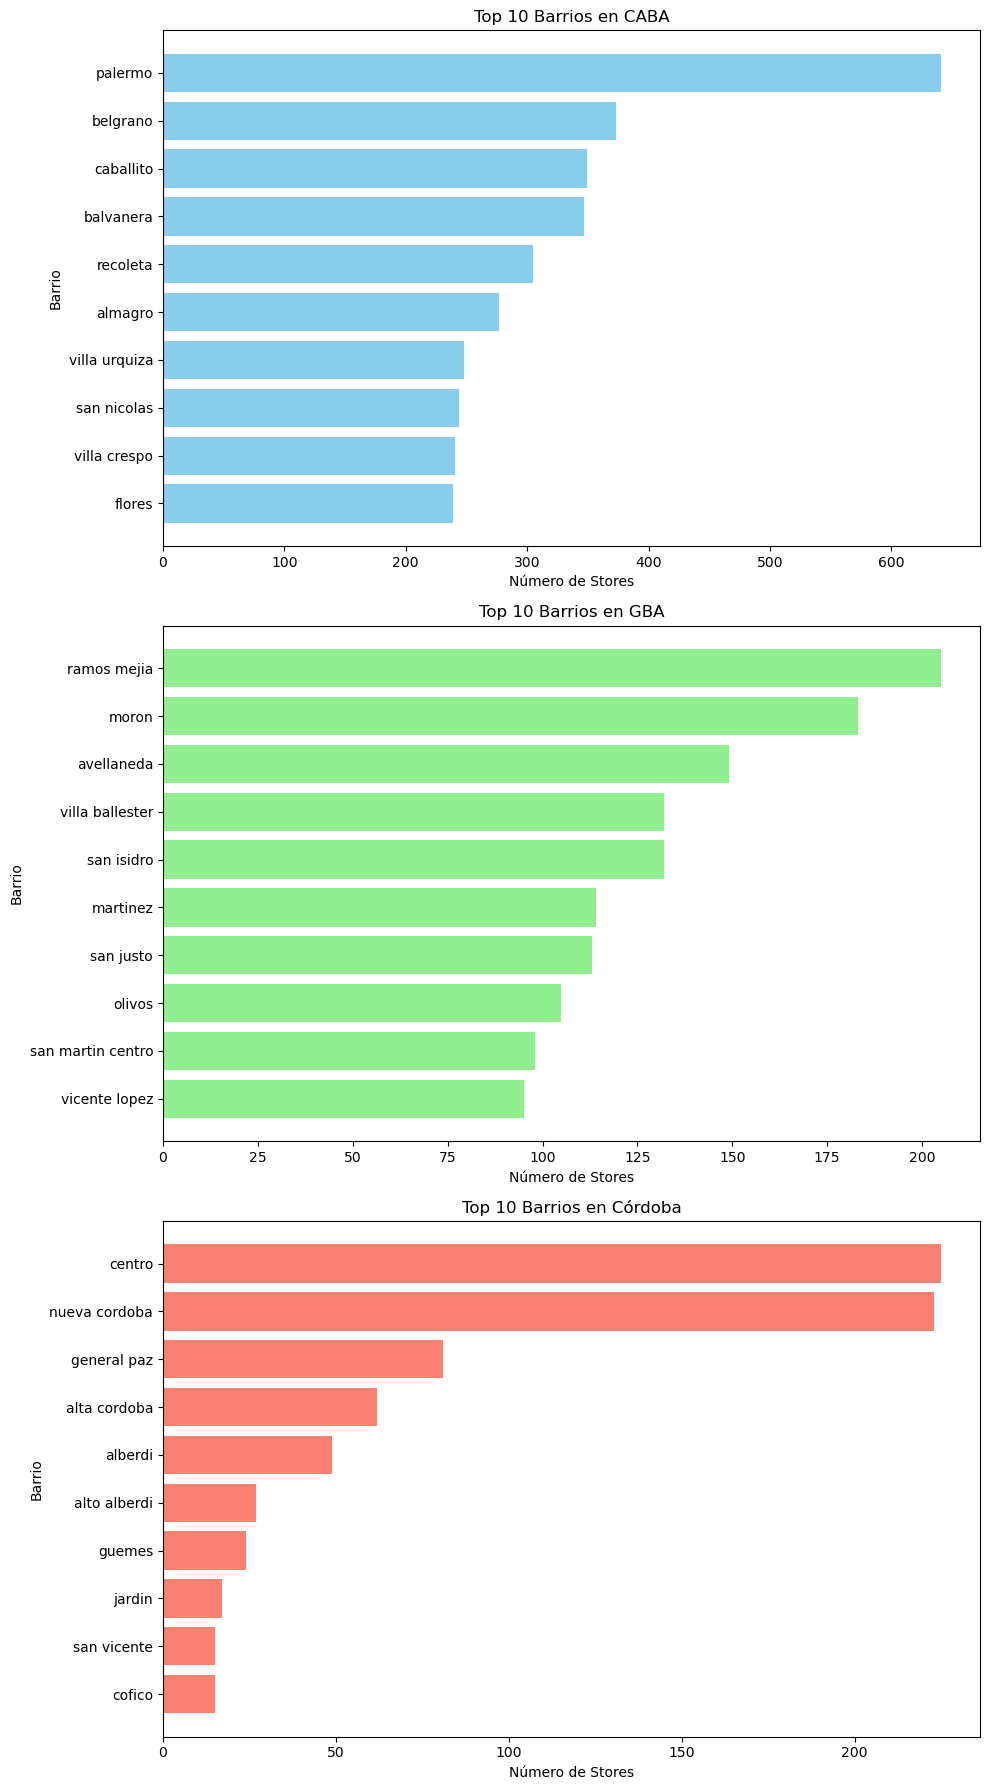

In [39]:
# 3. Dividir las tablas por ciudad (CABA, GBA, y Córdoba)
caba_barrio_counts = barrio_counts[barrio_counts['ciudad'] == 'CABA']
gba_barrio_counts = barrio_counts[barrio_counts['ciudad'] == 'GBA']
cordoba_barrio_counts = barrio_counts[barrio_counts['ciudad'] == 'Córdoba']

# Mostrar las tablas de cada ciudad
print("CABA Barrio Counts:")
display(caba_barrio_counts)

print("\nGBA Barrio Counts:")
display(gba_barrio_counts)

print("\nCórdoba Barrio Counts:")
display(cordoba_barrio_counts)

# 4. Gráficos de los top 10 barrios de cada ciudad
top_10_caba = caba_barrio_counts.nlargest(10, 'count').sort_values('count', ascending=True)
top_10_gba = gba_barrio_counts.nlargest(10, 'count').sort_values('count', ascending=True)
top_10_cordoba = cordoba_barrio_counts.nlargest(10, 'count').sort_values('count', ascending=True)

# Plot para cada ciudad
fig, axes = plt.subplots(3, 1, figsize=(10, 18))

# CABA
axes[0].barh(top_10_caba['barrio'], top_10_caba['count'], color='skyblue')
axes[0].set_title('Top 10 Barrios en CABA')
axes[0].set_xlabel('Número de Stores')
axes[0].set_ylabel('Barrio')

# GBA
axes[1].barh(top_10_gba['barrio'], top_10_gba['count'], color='lightgreen')
axes[1].set_title('Top 10 Barrios en GBA')
axes[1].set_xlabel('Número de Stores')
axes[1].set_ylabel('Barrio')

# Córdoba
axes[2].barh(top_10_cordoba['barrio'], top_10_cordoba['count'], color='salmon')
axes[2].set_title('Top 10 Barrios en Córdoba')
axes[2].set_xlabel('Número de Stores')
axes[2].set_ylabel('Barrio')

plt.tight_layout()
plt.show()

In [ ]:
# Procesamiento del dataframe orders
orders['store_id'] = orders['store_id'].fillna(0).astype(int).astype(str)

# Procesamiento del dataframe stages
stages = stages.drop(columns=['cus_cust_id'])
stages['store_id'] = stages['store_id'].fillna(0).astype(int).astype(str)

# Exploratory Analysis

## Stores

In [35]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10055 entries, 0 to 10054
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   created_date     10055 non-null  object 
 1   segmento         10054 non-null  object 
 2   comision_actual  9532 non-null   float64
 3   logistic_type    10055 non-null  object 
 4   barrio           10055 non-null  object 
 5   category         9324 non-null   object 
 6   cooking_time     9687 non-null   object 
 7   tiene_otra_app   9718 non-null   object 
 8   brand_id         10055 non-null  object 
 9   store_id         10055 non-null  object 
 10  ciudad           8798 non-null   object 
dtypes: float64(1), object(10)
memory usage: 864.2+ KB


Stores dados de alta en la plataforma por mes y por trimestre

Stores dados de alta por año:
   year_opened  store_count
0         2024         3895
1         2025         6069


/var/folders/k0/7nvdqhpx0t54_dcsz2cpy9nh0000gn/T/ipykernel_29478/2076861720.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stores_acotado['created_date'] = pd.to_datetime(stores_acotado['created_date'])
/var/folders/k0/7nvdqhpx0t54_dcsz2cpy9nh0000gn/T/ipykernel_29478/2076861720.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stores_acotado['year_opened'] = stores_acotado['created_date'].dt.year
/var/folders/k0/7nvdqhpx0t54_dcsz2cpy9nh0000gn/T/ipykernel_29478/2076861720.py:17: SettingWithCopyWarning

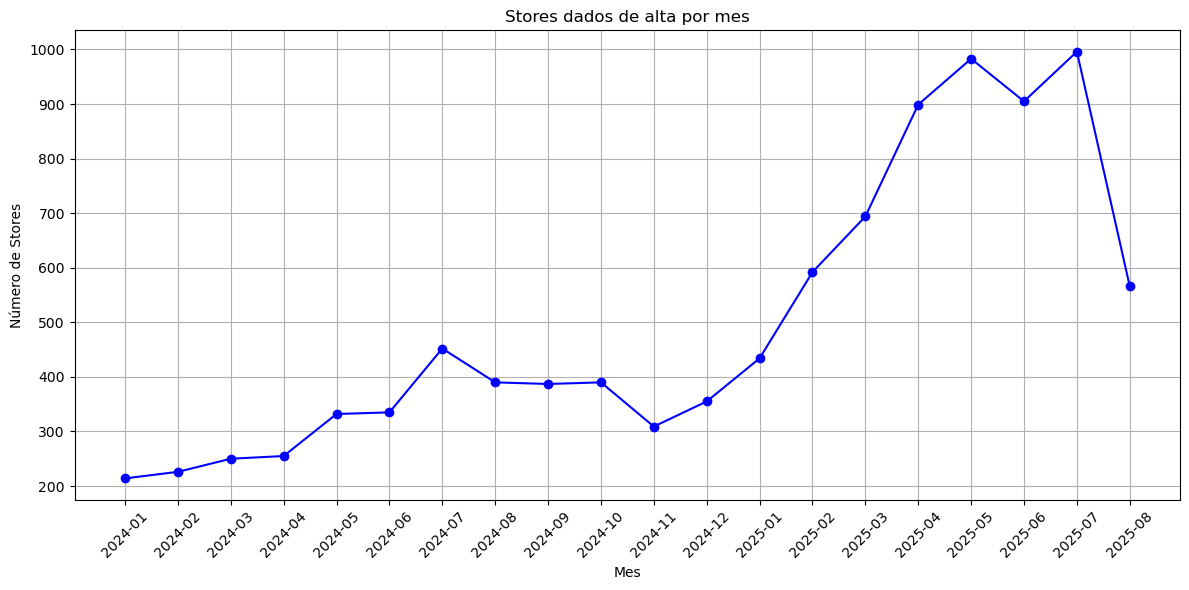


Stores dados de alta por trimestre:
  quarter_opened  store_count
0         2024Q1          690
1         2024Q2          922
2         2024Q3         1229
3         2024Q4         1054
4         2025Q1         1720
5         2025Q2         2787
6         2025Q3         1562


/var/folders/k0/7nvdqhpx0t54_dcsz2cpy9nh0000gn/T/ipykernel_29478/2076861720.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stores_acotado['quarter_opened'] = stores_acotado['created_date'].dt.to_period('Q')
/var/folders/k0/7nvdqhpx0t54_dcsz2cpy9nh0000gn/T/ipykernel_29478/2076861720.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stores_acotado['day_of_week_opened'] = stores_acotado['created_date'].dt.day_name()


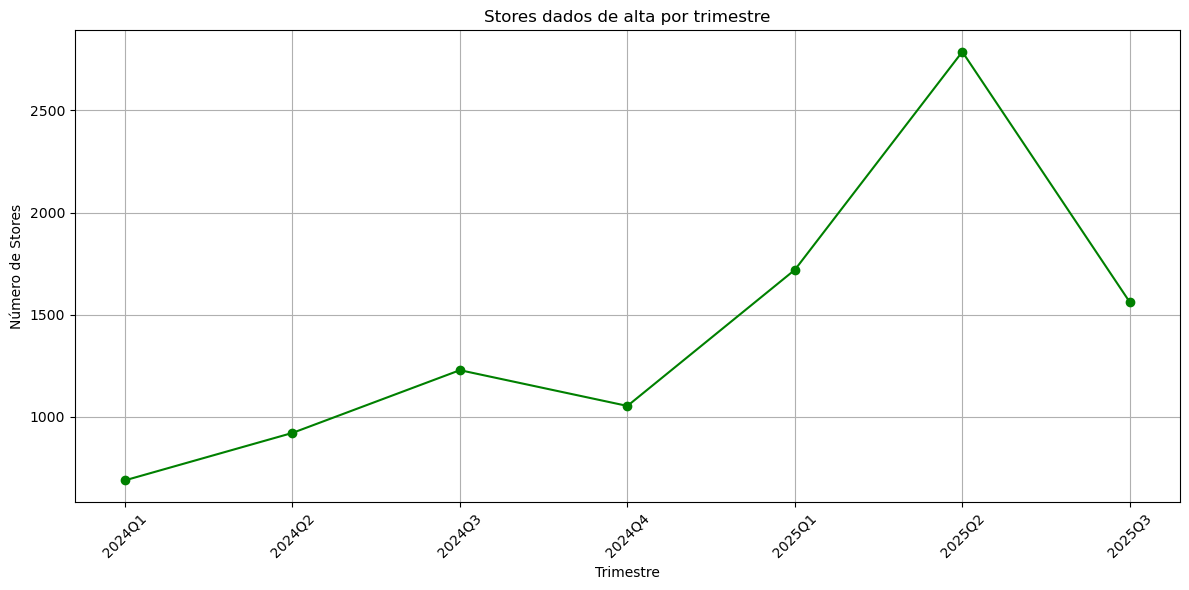

In [ ]:
# vemos solo hasta agosto 2025 porque como septiembre no está terminado, no tiene sentido analizarlo
stores_acotado = stores[stores['created_date'] <= '2025-08-31']

stores_acotado['created_date'] = pd.to_datetime(stores_acotado['created_date'])

stores_acotado['year_opened'] = stores_acotado['created_date'].dt.year
stores_per_year = stores_acotado.groupby('year_opened').size().reset_index(name='store_count')

print("Stores dados de alta por año:")
print(stores_per_year)

stores_acotado['month_opened'] = stores_acotado['created_date'].dt.to_period('M')
stores_per_month = stores_acotado.groupby('month_opened').size().reset_index(name='store_count')

plt.figure(figsize=(12, 6))
plt.plot(stores_per_month['month_opened'].astype(str), stores_per_month['store_count'], marker='o', color='b')
plt.title('Stores dados de alta por mes')
plt.xlabel('Mes')
plt.ylabel('Número de Stores')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

stores_acotado['quarter_opened'] = stores_acotado['created_date'].dt.to_period('Q')
stores_per_quarter = stores_acotado.groupby('quarter_opened').size().reset_index(name='store_count')

print("\nStores dados de alta por trimestre:")
print(stores_per_quarter)

stores_acotado['day_of_week_opened'] = stores_acotado['created_date'].dt.day_name()
stores_per_day_of_week = stores_acotado.groupby('day_of_week_opened').size().reset_index(name='store_count')

ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
stores_per_day_of_week['day_of_week_opened'] = pd.Categorical(stores_per_day_of_week['day_of_week_opened'], categories=ordered_days, ordered=True)
stores_per_day_of_week = stores_per_day_of_week.sort_values('day_of_week_opened')

plt.figure(figsize=(12, 6))
plt.plot(stores_per_quarter['quarter_opened'].astype(str), stores_per_quarter['store_count'], marker='o', color='g')
plt.title('Stores dados de alta por trimestre')
plt.xlabel('Trimestre')
plt.ylabel('Número de Stores')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Stores por segmento

In [43]:
segmento_counts = stores['segmento'].value_counts().reset_index()
segmento_counts.columns = ['segmento', 'count']

print("Cantidad de Stores por Segmento:")
print(segmento_counts)

Cantidad de Stores por Segmento:
        segmento  count
0    Microstores   7064
1    Top Players   1626
2  Picked Locals   1362
3              0      2


Eliminamos los casos de segemnto = 0 (son solo 2 y deben estar sin ssegmento por error)

In [45]:
stores = stores[stores['segmento'] != '0']

print("Filas restantes después de eliminar segmento = 0:")
print(stores['segmento'].value_counts())

Filas restantes después de eliminar segmento = 0:
segmento
Microstores      7064
Top Players      1626
Picked Locals    1362
Name: count, dtype: int64


Visualizamos la cantidad de stores que hay por cada segmento

/var/folders/k0/7nvdqhpx0t54_dcsz2cpy9nh0000gn/T/ipykernel_29478/2580780945.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segmento_counts, x='segmento', y='count', palette='viridis')


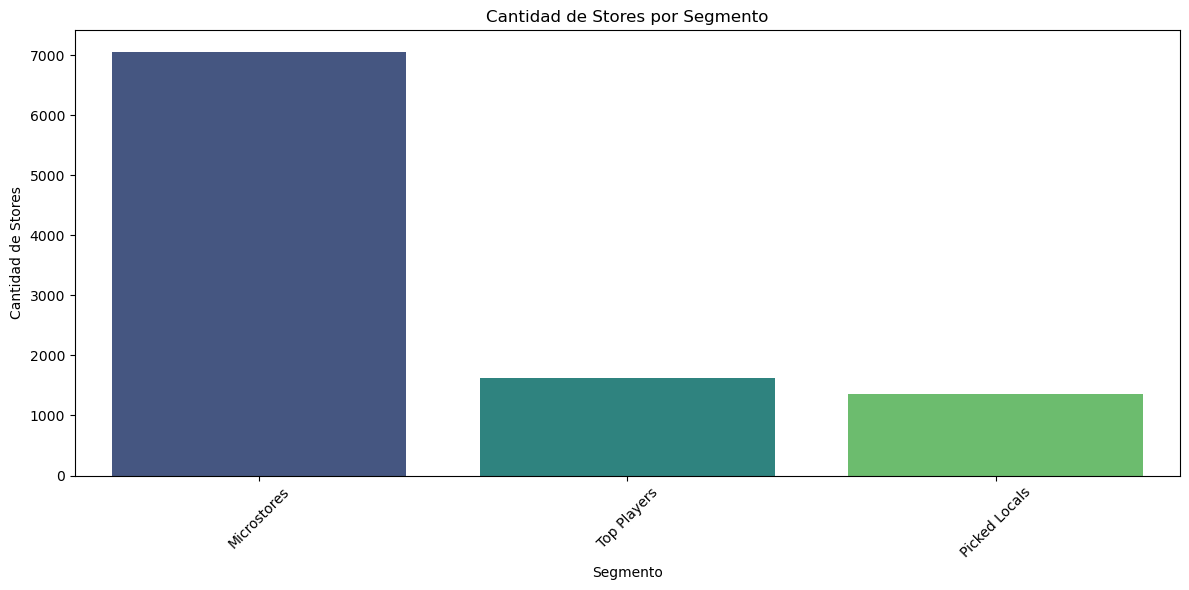

In [ ]:
segmento_counts = stores['segmento'].value_counts().reset_index()
segmento_counts.columns = ['segmento', 'count']

plt.figure(figsize=(12, 6))
sns.barplot(data=segmento_counts, x='segmento', y='count', palette='viridis')
plt.title('Cantidad de Stores por Segmento')
plt.xlabel('Segmento')
plt.ylabel('Cantidad de Stores')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Microstores: son las tiendas pequeñas (kioscos, almacenes, etc). Hay mucha cantidad.
- Top Players: son las tiendas que más volumen de ventas aportan. Grandes marcas.
- Picked Locals: son las tiendas que venden mucho pero tienen solo una sucursal, son populares y conocidas en el bario en el que están.

/var/folders/k0/7nvdqhpx0t54_dcsz2cpy9nh0000gn/T/ipykernel_29478/2763324368.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders_acotado['created_date'] = pd.to_datetime(orders_acotado['created_date'])
/var/folders/k0/7nvdqhpx0t54_dcsz2cpy9nh0000gn/T/ipykernel_29478/2763324368.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders_acotado['month_year'] = orders_acotado['created_date'].dt.to_period('M')


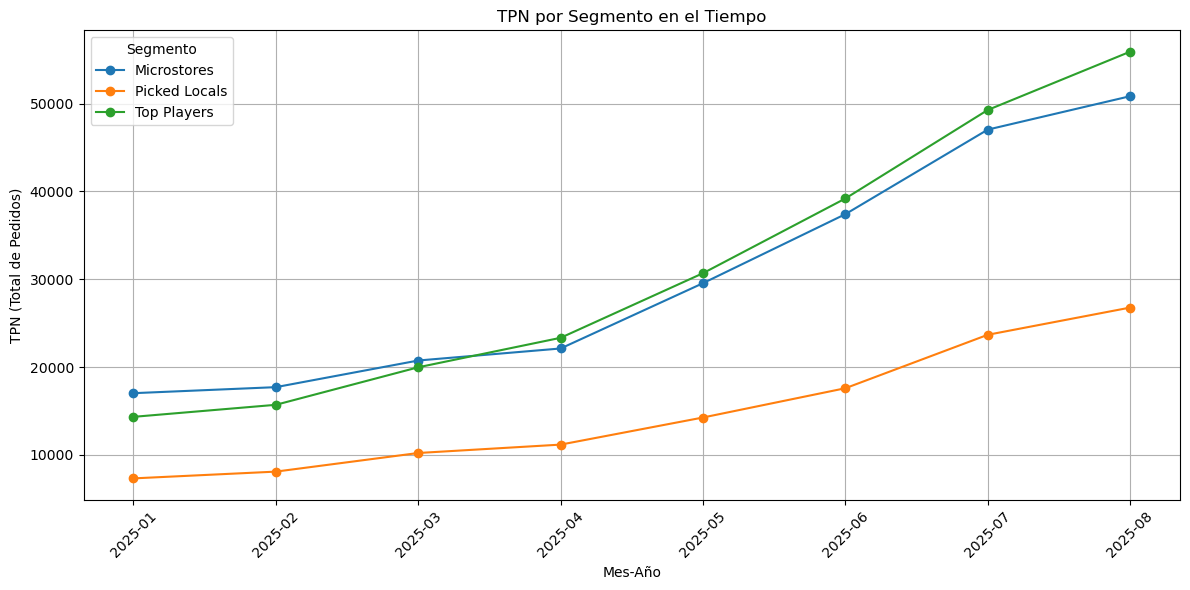

In [77]:
# vemos solo hasta agosto 2025 porque como septiembre no está terminado, no tiene sentido analizarlo
orders_acotado = orders[(orders['created_date'] <= '2025-08-31') & (pd.to_datetime(orders['created_date']).dt.year == 2025)]

orders_acotado['created_date'] = pd.to_datetime(orders_acotado['created_date'])
orders_acotado['month_year'] = orders_acotado['created_date'].dt.to_period('M')

orders_with_segmento = orders_acotado.merge(stores[['store_id', 'segmento']], on='store_id', how='inner')

tpn_per_segmento = orders_with_segmento.groupby(['segmento', 'month_year']).size().reset_index(name='tpn')

tpn_pivot = tpn_per_segmento.pivot(index='month_year', columns='segmento', values='tpn').fillna(0)

plt.figure(figsize=(12, 6))

for segmento in tpn_pivot.columns:
    plt.plot(tpn_pivot.index.astype(str), tpn_pivot[segmento], marker='o', label=f'{segmento}')

plt.title('TPN por Segmento en el Tiempo')
plt.xlabel('Mes-Año')
plt.ylabel('TPN (Total de Pedidos)')
plt.xticks(rotation=45)
plt.legend(title='Segmento')
plt.grid(True)
plt.tight_layout()
plt.show()

En los últimos 3 meses, el segmento Microstores es el que más tiendas en estado de churn tuvo.
Los otros dos segmentos presentaron una suba de churn en el mes de agosto, respecto a los meses anteriores.
Esto tiene en cuenta los casos de 'churn entrante' y 'churn sostenido'; el primer caso es cuando un store entra en churn de un mes a otro y el segundo es cuando ya viene de un mes en churn y continúa este mes en el mismo estado.

Cantidad de churn para segmento en los últimos 3 meses:
segmento  Microstores  Picked Locals  Top Players
month                                            
6                1251            192          104
7                1449            212          122
8                1767            250          167


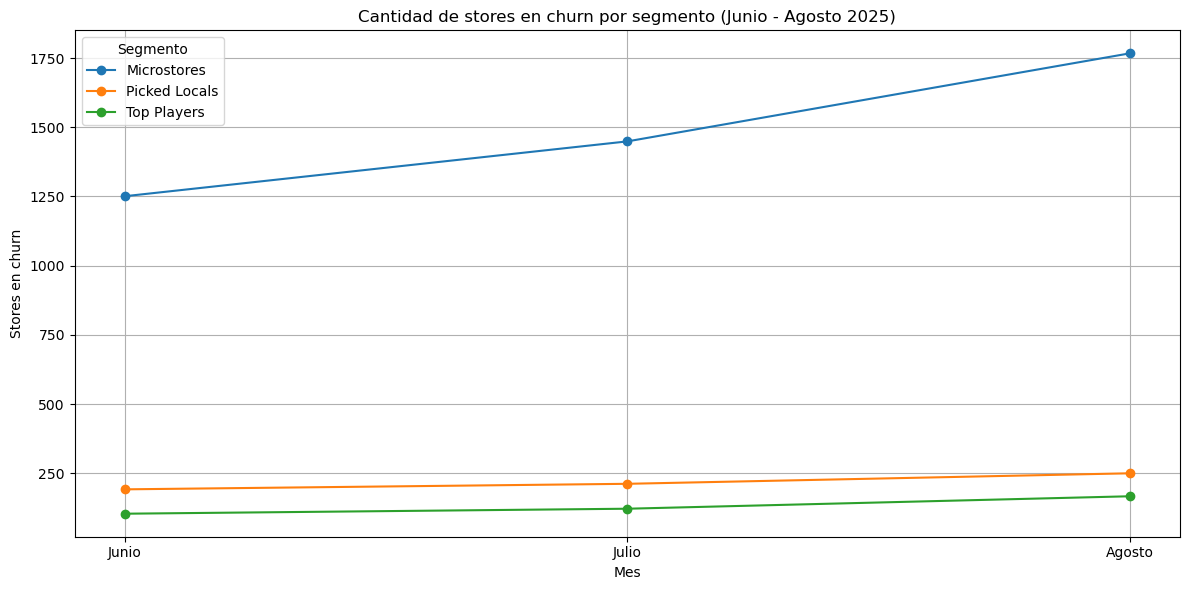

In [61]:
# Filter the stages dataframe for the months 6, 7, and 8 of 2025
stages_filtered = stages[(stages['year'] == 2025) & (stages['month'].isin([6, 7, 8]))]

stages_churn = stages_filtered[stages_filtered['STORE_STAGE_LIFECYCLE'].str.contains('Churn', na=False)]

churn_with_segmento = stages_churn.merge(stores[['store_id', 'segmento']], on='store_id', how='inner')

churn_counts = churn_with_segmento.groupby(['month', 'segmento']).size().reset_index(name='churn_count')

churn_pivot = churn_counts.pivot(index='month', columns='segmento', values='churn_count').fillna(0)

print("Cantidad de churn para segmento en los últimos 3 meses:")
print(churn_pivot)

plt.figure(figsize=(12, 6))

for segmento in churn_pivot.columns:
    plt.plot(churn_pivot.index, churn_pivot[segmento], marker='o', label=f'{segmento}')

plt.title('Cantidad de stores en churn por segmento (Junio - Agosto 2025)')
plt.xlabel('Mes')
plt.ylabel('Stores en churn')
plt.xticks([6, 7, 8], ['Junio', 'Julio', 'Agosto'])
plt.legend(title='Segmento')
plt.grid(True)
plt.tight_layout()
plt.show()

Analizamos solamente los stores que son del caso de 'churn entrante'.

CCantidad de churn para segmento en los últimos 3 meses:
segmento  Microstores  Picked Locals  Top Players
month                                            
6                  29             13            3
7                  32             10            5
8                  43             14           10


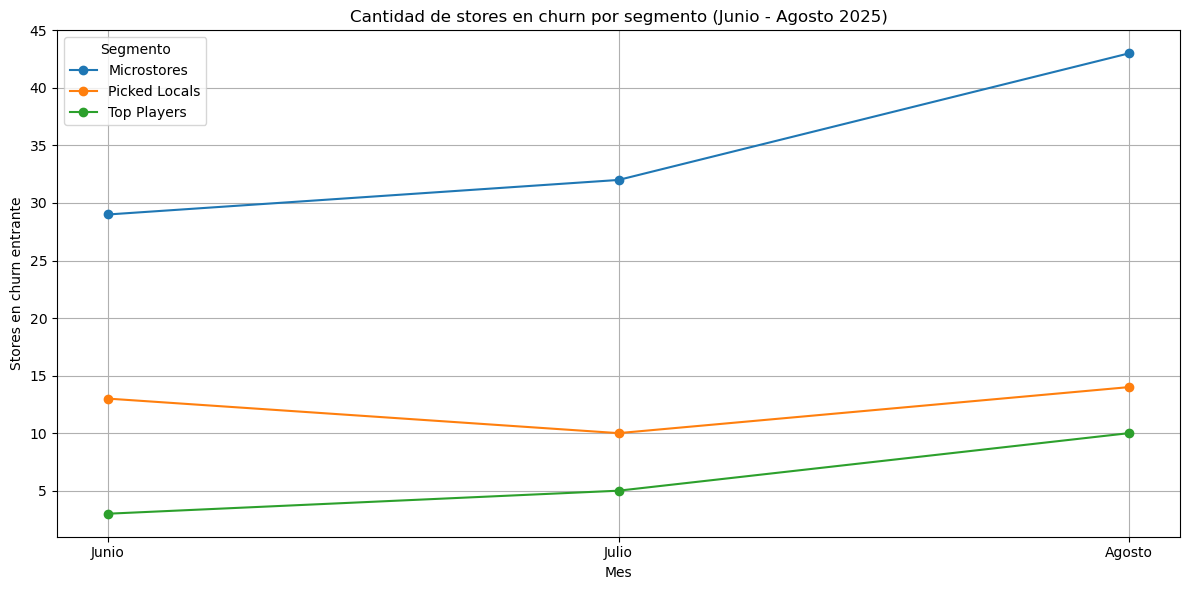

In [59]:
stages_churn_entrante = stages_filtered[stages_filtered['STORE_STAGE_LIFECYCLE'] == 'Churn']

churn_with_segmento = stages_churn_entrante.merge(stores[['store_id', 'segmento']], on='store_id', how='inner')

churn_counts = churn_with_segmento.groupby(['month', 'segmento']).size().reset_index(name='churn_count')

churn_pivot = churn_counts.pivot(index='month', columns='segmento', values='churn_count').fillna(0)

print("CCantidad de churn para segmento en los últimos 3 meses:")
print(churn_pivot)

plt.figure(figsize=(12, 6))

for segmento in churn_pivot.columns:
    plt.plot(churn_pivot.index, churn_pivot[segmento], marker='o', label=f'{segmento}')

plt.title('Cantidad de stores en churn por segmento (Junio - Agosto 2025)')
plt.xlabel('Mes')
plt.ylabel('Stores en churn entrante')
plt.xticks([6, 7, 8], ['Junio', 'Julio', 'Agosto'])
plt.legend(title='Segmento')
plt.grid(True)
plt.tight_layout()
plt.show()

Se nota la diferencia entre ambos tipos de churn, ya que hay muchos stores que vienen en un churn sostenido hace varios meses.

### Stores por categoría

In [72]:
category_counts = stores['category'].value_counts().reset_index()
category_counts.columns = ['category', 'count']

with pd.option_context('display.max_rows', None): 
    print("Cantidad de Stores por category:")
    print(category_counts)

Cantidad de Stores por category:
                 category  count
0   Desayunos y meriendas   1237
1               Empanadas   1214
2                  Helado    915
3                   Pizza    781
4             Hamburguesa    761
5              Sándwiches    479
6                   Sushi    425
7               Panadería    384
8               Milanesas    381
9               Argentina    360
10          Internacional    330
11              Saludable    275
12          Comida rápida    187
13             Venezolana    181
14                 Pastas    165
15                Bebidas    156
16                   Café    155
17                  Pollo    142
18               Parrilla    138
19              Ensaladas     98
20                Picadas     78
21               Asiática     68
22                  Árabe     68
23                Peruana     64
24                  China     58
25                 Carnes     45
26                Postres     39
27                 Arepas     28
28        

/var/folders/k0/7nvdqhpx0t54_dcsz2cpy9nh0000gn/T/ipykernel_29478/3731118355.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders_acotado['created_date'] = pd.to_datetime(orders_acotado['created_date'])
/var/folders/k0/7nvdqhpx0t54_dcsz2cpy9nh0000gn/T/ipykernel_29478/3731118355.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders_acotado['month_year'] = orders_acotado['created_date'].dt.to_period('M')


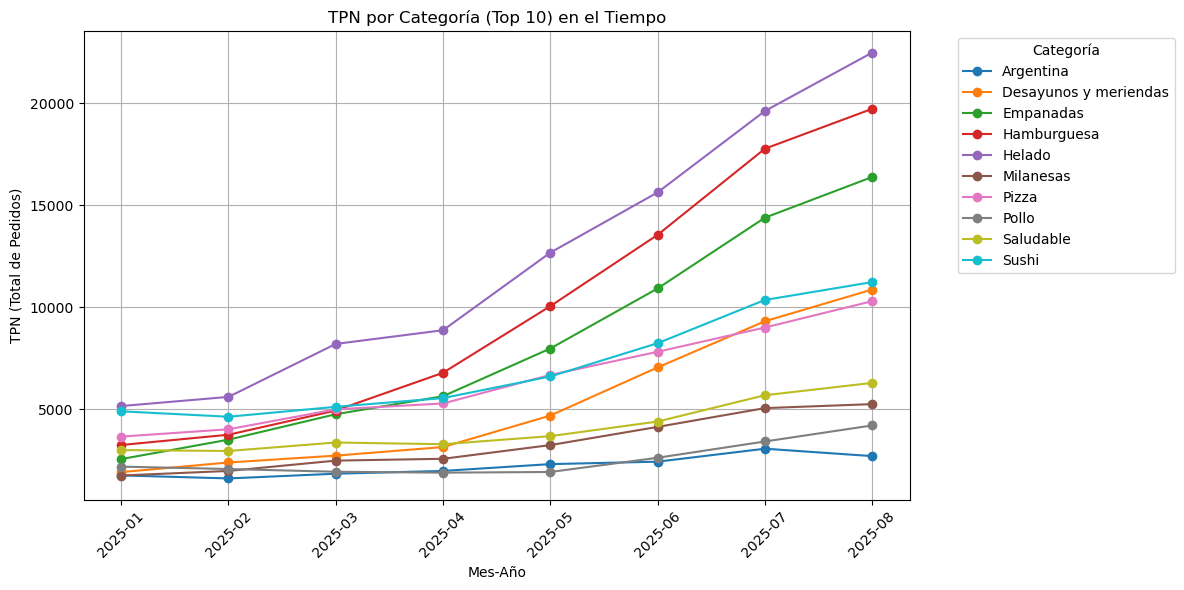

In [76]:
orders_acotado = orders[(orders['created_date'] <= '2025-08-31') & (pd.to_datetime(orders['created_date']).dt.year == 2025)]

orders_acotado['created_date'] = pd.to_datetime(orders_acotado['created_date'])
orders_acotado['month_year'] = orders_acotado['created_date'].dt.to_period('M')

orders_with_category = orders_acotado.merge(stores[['store_id', 'category']], on='store_id', how='inner')

tpn_per_category = orders_with_category.groupby(['category', 'month_year']).size().reset_index(name='tpn')

total_tpn_per_category = tpn_per_category.groupby('category')['tpn'].sum().reset_index()

top_10_categories = total_tpn_per_category.nlargest(10, 'tpn')['category']

tpn_top_10 = tpn_per_category[tpn_per_category['category'].isin(top_10_categories)]

tpn_pivot = tpn_top_10.pivot(index='month_year', columns='category', values='tpn').fillna(0)

plt.figure(figsize=(12, 6))

for category in tpn_pivot.columns:
    plt.plot(tpn_pivot.index.astype(str), tpn_pivot[category], marker='o', label=f'{category}')

plt.title('TPN por Categoría (Top 10) en el Tiempo')
plt.xlabel('Mes-Año')
plt.ylabel('TPN (Total de Pedidos)')
plt.xticks(rotation=45)
plt.legend(title='Categoría', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

Cantidad de churn para las 10 principales categorías en los últimos 3 meses:
category  Argentina  Desayunos y meriendas  Empanadas  Hamburguesa  Helado  \
month                                                                        
3                80                    119         60           45      50   
4                92                    134         79           48      60   
5                88                    168        104           60      73   
6                96                    190        117           77      95   
7                99                    234        143           97     111   
8               120                    297        194          130     138   

category  Internacional  Panadería  Pizza  Sushi  Sándwiches  
month                                                         
3                    57         50     96     39          55  
4                    64         57    106     45          74  
5                    67         66    129     

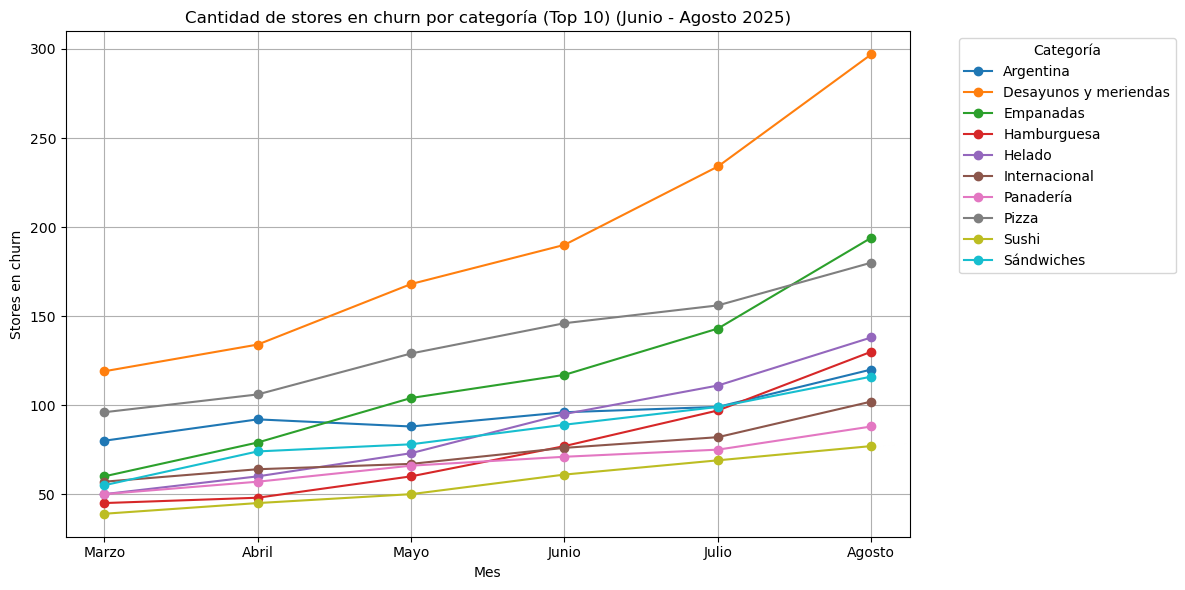

In [84]:
stages_filtered = stages[(stages['year'] == 2025) & (stages['month'].isin([3, 4, 5, 6, 7, 8]))]

stages_churn = stages_filtered[stages_filtered['STORE_STAGE_LIFECYCLE'].str.contains('Churn', na=False)]

churn_with_category = stages_churn.merge(stores[['store_id', 'category']], on='store_id', how='inner')

churn_counts = churn_with_category.groupby(['month', 'category']).size().reset_index(name='churn_count')

top_10_categories = churn_counts.groupby('category')['churn_count'].sum().nlargest(10).index

churn_counts_top_10 = churn_counts[churn_counts['category'].isin(top_10_categories)]

churn_pivot = churn_counts_top_10.pivot(index='month', columns='category', values='churn_count').fillna(0)

print("Cantidad de churn para las 10 principales categorías en los últimos 3 meses:")
print(churn_pivot)

plt.figure(figsize=(12, 6))

for category in churn_pivot.columns:
    plt.plot(churn_pivot.index, churn_pivot[category], marker='o', label=f'{category}')

plt.title('Cantidad de stores en churn por categoría (Top 10) (Junio - Agosto 2025)')
plt.xlabel('Mes')
plt.ylabel('Stores en churn')
plt.xticks([3, 4, 5, 6, 7, 8], ['Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto'])
plt.legend(title='Categoría', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

Cantidad de churn para la categoría principal en los últimos 6 meses:
category  Café  Desayunos y meriendas  Empanadas  Hamburguesa  Helado  \
month                                                                   
3          1.0                    2.0        0.0          0.0     0.0   
4          0.0                    2.0        2.0          0.0     1.0   
5          1.0                    4.0        3.0          1.0     5.0   
6          0.0                    4.0        2.0          8.0     4.0   
7          2.0                    5.0        2.0          4.0     4.0   
8          6.0                   10.0        3.0          1.0     4.0   

category  Internacional  Pizza  Saludable  Sushi  Sándwiches  
month                                                         
3                   0.0    0.0        0.0    0.0         1.0  
4                   4.0    1.0        1.0    2.0         2.0  
5                   2.0    8.0        2.0    1.0         0.0  
6                   0.0    6.0

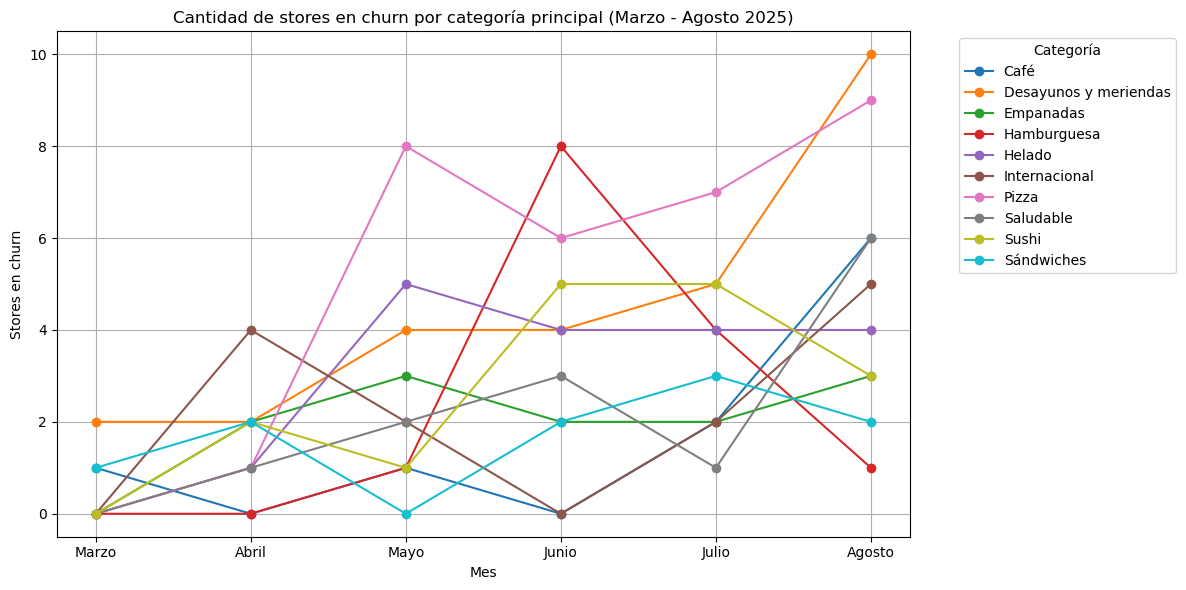

In [ ]:
stages_churn = stages_filtered[stages_filtered['STORE_STAGE_LIFECYCLE'] == 'Churn']

churn_with_category = stages_churn.merge(stores[['store_id', 'category']], on='store_id', how='inner')

churn_counts = churn_with_category.groupby(['month', 'category']).size().reset_index(name='churn_count')

top_1_category = churn_counts.groupby('category')['churn_count'].sum().nlargest(10).index

churn_counts_top_1 = churn_counts[churn_counts['category'].isin(top_1_category)]

churn_pivot = churn_counts_top_1.pivot(index='month', columns='category', values='churn_count').fillna(0)

print("Cantidad de churn para la categoría principal en los últimos 6 meses:")
print(churn_pivot)

plt.figure(figsize=(12, 6))

for category in churn_pivot.columns:
    plt.plot(churn_pivot.index, churn_pivot[category], marker='o', label=f'{category}')

plt.title('Cantidad de stores en churn por categoría principal (Marzo - Agosto 2025)')
plt.xlabel('Mes')
plt.ylabel('Stores en churn')
plt.xticks([3, 4, 5, 6, 7, 8], ['Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto'])
plt.legend(title='Categoría', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

Las categorías Desayunos y meriendas y Pizza son las que más crecieron en churn entrante en los últimos meses.

/var/folders/k0/7nvdqhpx0t54_dcsz2cpy9nh0000gn/T/ipykernel_29478/1834495495.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_categories, y='category', x='churn_count', palette='viridis')


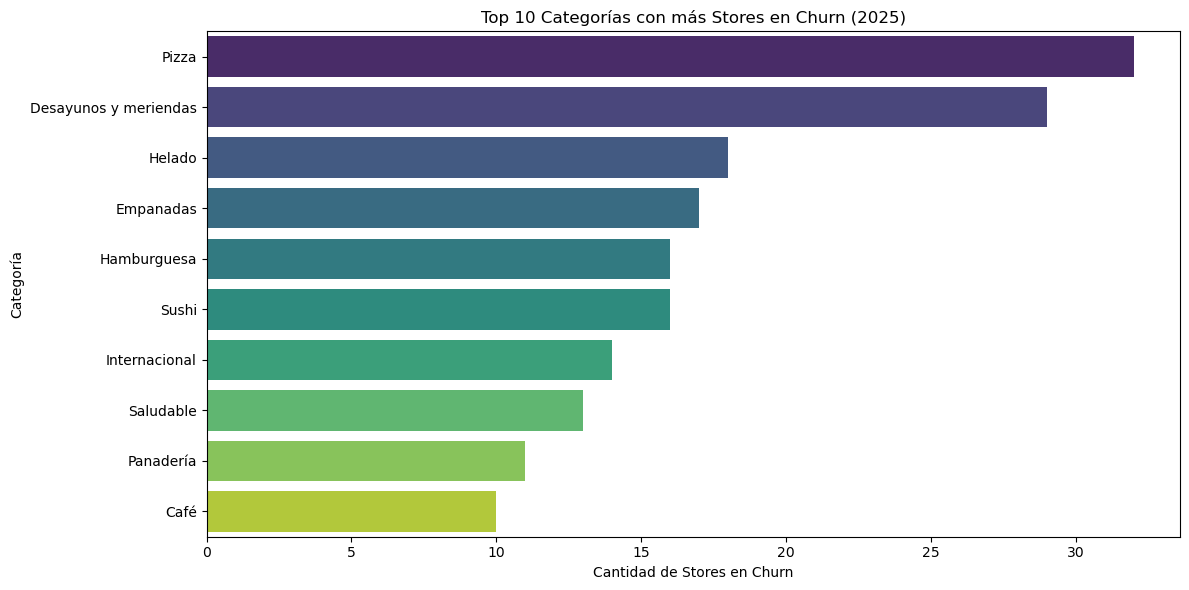

In [ ]:
stages_filtered = stages[stages['year'] == 2025]

stages_churn = stages_filtered[stages_filtered['STORE_STAGE_LIFECYCLE'] == 'Churn']

churn_with_category = stages_churn.merge(stores[['store_id', 'category']], on='store_id', how='inner')

churn_counts = churn_with_category.groupby('category').size().reset_index(name='churn_count')

top_10_categories = churn_counts.nlargest(10, 'churn_count')

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_categories, y='category', x='churn_count', palette='viridis')
plt.title('Top 10 Categorías con más Stores en Churn (2025)')
plt.xlabel('Cantidad de Stores en Churn')
plt.ylabel('Categoría')
plt.tight_layout()
plt.show()

- En lo que va del año, la cetgoría Pizza es la que más stores en churn tuvo (más de 30).
- Desayunos y meriendas sigue, también con un número alto de churn, cercano a 30.

/var/folders/k0/7nvdqhpx0t54_dcsz2cpy9nh0000gn/T/ipykernel_29478/2829153167.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=combined_data, x='category', y='tpn', ax=ax1, palette='viridis')
/var/folders/k0/7nvdqhpx0t54_dcsz2cpy9nh0000gn/T/ipykernel_29478/2829153167.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


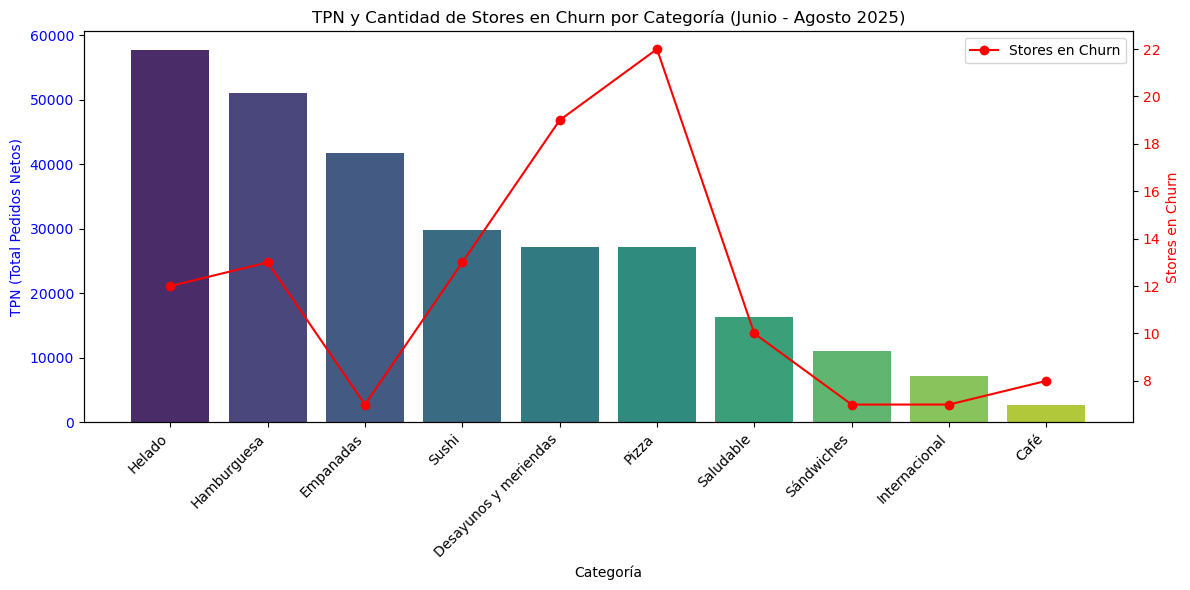

In [ ]:
stages_filtered = stages[(stages['year'] == 2025) & (stages['month'].isin([6, 7, 8]))]

stages_churn = stages_filtered[stages_filtered['STORE_STAGE_LIFECYCLE'] == 'Churn']

churn_with_category = stages_churn.merge(stores[['store_id', 'category']], on='store_id', how='inner')

churn_counts = churn_with_category.groupby('category').size().reset_index(name='churn_count')

top_10_categories = churn_counts.nlargest(10, 'churn_count')['category']

orders_filtered = orders[(orders['created_date'] >= '2025-06-01') & (orders['created_date'] <= '2025-08-31')]
orders_with_category = orders_filtered.merge(stores[['store_id', 'category']], on='store_id', how='inner')

orders_top_10 = orders_with_category[orders_with_category['category'].isin(top_10_categories)]

tpn_per_category = orders_top_10.groupby('category').size().reset_index(name='tpn')

combined_data = pd.merge(tpn_per_category, churn_counts, on='category')

combined_data = combined_data.sort_values('tpn', ascending=False)

fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(data=combined_data, x='category', y='tpn', ax=ax1, palette='viridis')
ax1.set_ylabel('TPN (Total Pedidos Netos)', color='b')
ax1.set_xlabel('Categoría')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_title('TPN y Cantidad de Stores en Churn por Categoría (Junio - Agosto 2025)')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(combined_data['category'], combined_data['churn_count'], color='r', marker='o', label='Stores en Churn')
ax2.set_ylabel('Stores en Churn', color='r')
ax2.tick_params(axis='y', labelcolor='r')

ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

- Las categorías Helado, Hamburguesa y Empanadas tienen un alto TPN y un Churn muy bajo.
- Las. categorías Sushi, Desayunos y meriendas, Pizza y Café tienen un TPN no tan alto y un Churn muy alto.